In [1]:
import pandas as pd
from pathlib import Path

In [10]:
final_ds = Path('..', 'Dataset', 'pre-processed', 'final_preprocessed_good_data.csv')
final_ds.exists()

True

In [11]:
df = pd.read_csv(final_ds)

/tmp/ipykernel_269366/3637337491.py:1: DtypeWarning: Columns (0: CH3 Resistance Break, 1: CH4 Resistance Break, 2: CH3 Bounce Break, 3: CH4 Bounce Break, 4: CH1 Resistance Break, 5: CH2 Resistance Break, 6: CH1 Bounce Break, 7: CH2 Bounce Break) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(final_ds)


In [12]:
df.head()

,Coil Current C1 (A),Coil Current C2 (A),Coil Current C3 (A),Coil Current C4 (A),Coil Current C5 (A),Coil Current C6 (A),Contact Travel T1 (mm),Contact Travel T2 (mm),Contact Travel T3 (mm),Contact Travel T4 (mm),...,phase,CH3 Resistance Break,CH4 Resistance Break,CH3 Bounce Break,CH4 Bounce Break,breaker_id,CH1 Resistance Break,CH2 Resistance Break,CH1 Bounce Break,CH2 Bounce Break
0,0.000,0.000,0.000,0.029,0.0,0.0,0.0,0.0,0.0,0.85,...,Y,NaN,NaN,NaN,NaN,407,NaN,NaN,NaN,NaN
1,0.000,0.000,0.000,0.037,0.0,0.0,0.0,0.0,0.0,-0.26,...,Y,NaN,NaN,NaN,NaN,407,NaN,NaN,NaN,NaN
2,0.000,0.000,0.000,0.051,0.0,0.0,0.0,0.0,0.0,-0.02,...,Y,NaN,NaN,NaN,NaN,407,NaN,NaN,NaN,NaN
3,0.029,0.044,0.037,0.029,0.0,0.0,0.0,0.0,0.0,0.14,...,Y,NaN,NaN,NaN,NaN,407,NaN,NaN,NaN,NaN
4,0.066,0.073,0.066,0.051,0.0,0.0,0.0,0.0,0.0,-0.02,...,Y,NaN,NaN,NaN,NaN,407,NaN,NaN,NaN,NaN


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49500 entries, 0 to 49499
Data columns (total 52 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Coil Current C1 (A)       49500 non-null  float64
 1   Coil Current C2 (A)       49500 non-null  float64
 2   Coil Current C3 (A)       49500 non-null  float64
 3   Coil Current C4 (A)       49500 non-null  float64
 4   Coil Current C5 (A)       49500 non-null  float64
 5   Coil Current C6 (A)       49500 non-null  float64
 6   Contact Travel T1 (mm)    49500 non-null  float64
 7   Contact Travel T2 (mm)    49500 non-null  float64
 8   Contact Travel T3 (mm)    49500 non-null  float64
 9   Contact Travel T4 (mm)    49500 non-null  float64
 10  Contact Travel T5 (mm)    49500 non-null  int64  
 11  Contact Travel T6 (mm)    49500 non-null  int64  
 12  DCRM Res CH1 in uOhm      49500 non-null  float64
 13  DCRM Current CH1 in Amp   49500 non-null  float64
 14  CH1 Close-Velocit

In [14]:
df['phase'].value_counts()

phase
B      18000
R      13500
Y       9000
R,Y     9000
Name: count, dtype: int64

In [16]:
df[['CH1 Test Run', 'CH2 Test Run', 'CH3 Test Run', 'CH4 Test Run', 'CH5 Test Run', 'CH6 Test Run']].value_counts()

CH1 Test Run  CH2 Test Run  CH3 Test Run  CH4 Test Run  CH5 Test Run  CH6 Test Run
TR2           TR2           TR2           TR2           TR2           TR2             31500
TR6           TR6           TR6           TR6           TR6           TR6              9000
TR3           TR3           TR3           TR3           TR3           TR3              4500
TR1           TR1           TR1           TR1           TR1           TR1              4500
Name: count, dtype: int64

In [17]:
drop = ['CH1 Test Run', 'CH2 Test Run', 'CH3 Test Run',
             'CH4 Test Run', 'CH5 Test Run', 'CH6 Test Run',
             'CH1 Resistance Break', 'CH2 Resistance Break',
             'CH3 Resistance Break', 'CH4 Resistance Break',
             'CH1 Bounce Break', 'CH2 Bounce Break',
             'CH3 Bounce Break', 'CH4 Bounce Break']

df.drop(columns=drop, inplace=True)

In [18]:
for ch in ['CH1', 'CH2', 'CH3', 'CH4', 'CH5', 'CH6']:
    res_col = f'DCRM Res {ch} in uOhm'
    cur_col = f'DCRM Current {ch} in Amp'
    
    # Rate of change — catches resistance transitions
    df[f'{ch}_dR_dt'] = df[res_col].diff().fillna(0)
    
    # Local volatility — catches bouncing/instability
    df[f'{ch}_rolling_std'] = df[res_col].rolling(50).std().fillna(0)
    
    # Normalized resistance — removes current injection variation
    df[f'{ch}_res_normalized'] = df[res_col] / (df[cur_col] + 1e-9)
    
    # Cumulative energy proxy — catches sustained high resistance
    df[f'{ch}_cumulative_res'] = df[res_col].cumsum()
    
    # Deviation from local mean — catches local spikes
    df[f'{ch}_local_deviation'] = (
        df[res_col] - df[res_col].rolling(100).mean()
    ).fillna(0)

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
healthy_df = df

In [21]:
faulty = Path('..', 'Dataset', 'pre-processed', '402_faulty', 'processed_402_R_faulty.csv')
faulty_df = pd.read_csv(faulty)
faulty_df.head()

,Coil Current C1 (A),Coil Current C2 (A),Coil Current C3 (A),Coil Current C4 (A),Coil Current C5 (A),Coil Current C6 (A),Unnamed: 6,Contact Travel T1 (mm),Contact Travel T2 (mm),Contact Travel T3 (mm),...,DCRM Current CH5 in Amp,CH5 Close-Velocity (m/s),CH5 Open-Velocity (m/s),CH5 Test Run,DCRM Res CH6 in uOhm,DCRM Current CH6 in Amp,CH6 Close-Velocity (m/s),CH6 Open-Velocity (m/s),CH6 Test Run,phase
0,0.015,0.029,0.015,0.029,0.0,0.0,,0,0,0,...,0,0,0.12,TR4,368.25,0,0,0.12,TR4,R
1,0.007,0.022,0.000,0.037,0.0,0.0,,0,0,0,...,0,0,0.12,TR4,379.98,0,0,0.12,TR4,R
2,0.051,0.007,0.000,0.066,0.0,0.0,,0,0,0,...,0,0,0.12,TR4,378.02,0,0,0.12,TR4,R
3,0.161,0.029,0.000,0.051,0.0,0.0,,0,0,0,...,0,0,0.12,TR4,393.65,0,0,0.12,TR4,R
4,0.286,0.022,0.015,0.029,0.0,0.0,,0,0,0,...,0,0,0.12,TR4,393.65,0,0,0.12,TR4,R


In [25]:
faulty_df.drop('Unnamed: 6',axis=1, inplace=True)
faulty_df.head()

KeyError: "['Unnamed: 6'] not found in axis"

In [26]:
faulty_df.head()

,Coil Current C1 (A),Coil Current C2 (A),Coil Current C3 (A),Coil Current C4 (A),Coil Current C5 (A),Coil Current C6 (A),Contact Travel T1 (mm),Contact Travel T2 (mm),Contact Travel T3 (mm),Contact Travel T4 (mm),...,DCRM Current CH5 in Amp,CH5 Close-Velocity (m/s),CH5 Open-Velocity (m/s),CH5 Test Run,DCRM Res CH6 in uOhm,DCRM Current CH6 in Amp,CH6 Close-Velocity (m/s),CH6 Open-Velocity (m/s),CH6 Test Run,phase
0,0.015,0.029,0.015,0.029,0.0,0.0,0,0,0,0.10,...,0,0,0.12,TR4,368.25,0,0,0.12,TR4,R
1,0.007,0.022,0.000,0.037,0.0,0.0,0,0,0,-0.06,...,0,0,0.12,TR4,379.98,0,0,0.12,TR4,R
2,0.051,0.007,0.000,0.066,0.0,0.0,0,0,0,0.02,...,0,0,0.12,TR4,378.02,0,0,0.12,TR4,R
3,0.161,0.029,0.000,0.051,0.0,0.0,0,0,0,0.10,...,0,0,0.12,TR4,393.65,0,0,0.12,TR4,R
4,0.286,0.022,0.015,0.029,0.0,0.0,0,0,0,0.18,...,0,0,0.12,TR4,393.65,0,0,0.12,TR4,R


In [27]:
faulty_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 45 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Coil Current C1 (A)       4500 non-null   float64
 1   Coil Current C2 (A)       4500 non-null   float64
 2   Coil Current C3 (A)       4500 non-null   float64
 3   Coil Current C4 (A)       4500 non-null   float64
 4   Coil Current C5 (A)       4500 non-null   float64
 5   Coil Current C6 (A)       4500 non-null   float64
 6   Contact Travel T1 (mm)    4500 non-null   int64  
 7   Contact Travel T2 (mm)    4500 non-null   int64  
 8   Contact Travel T3 (mm)    4500 non-null   int64  
 9   Contact Travel T4 (mm)    4500 non-null   float64
 10  Contact Travel T5 (mm)    4500 non-null   int64  
 11  Contact Travel T6 (mm)    4500 non-null   int64  
 12  DCRM Res CH1 in uOhm      4500 non-null   int64  
 13  DCRM Current CH1 in Amp   4500 non-null   int64  
 14  CH1 Close-Velocity 

In [28]:
print(set(healthy_df.columns) - set(faulty_df.columns))

{'CH3_local_deviation', 'CH5_rolling_std', 'CH2_local_deviation', 'CH6_res_normalized', 'CH2_cumulative_res', 'CH1_cumulative_res', 'CH2_dR_dt', 'CH6_dR_dt', 'CH1_rolling_std', 'CH4_local_deviation', 'CH5_local_deviation', 'CH6_rolling_std', 'CH4_res_normalized', 'CH4_cumulative_res', 'CH1_dR_dt', 'CH2_rolling_std', 'CH5_cumulative_res', 'CH3_cumulative_res', 'CH5_dR_dt', 'CH1_local_deviation', 'CH5_res_normalized', 'CH6_local_deviation', 'CH4_rolling_std', 'CH6_cumulative_res', 'breaker_id', 'CH3_dR_dt', 'CH2_res_normalized', 'CH4_dR_dt', 'CH1_res_normalized', 'CH3_res_normalized', 'CH3_rolling_std'}


In [29]:
df = faulty_df

In [30]:
for ch in ['CH1', 'CH2', 'CH3', 'CH4', 'CH5', 'CH6']:
    res_col = f'DCRM Res {ch} in uOhm'
    cur_col = f'DCRM Current {ch} in Amp'
    
    # Rate of change — catches resistance transitions
    df[f'{ch}_dR_dt'] = df[res_col].diff().fillna(0)
    
    # Local volatility — catches bouncing/instability
    df[f'{ch}_rolling_std'] = df[res_col].rolling(50).std().fillna(0)
    
    # Normalized resistance — removes current injection variation
    df[f'{ch}_res_normalized'] = df[res_col] / (df[cur_col] + 1e-9)
    
    # Cumulative energy proxy — catches sustained high resistance
    df[f'{ch}_cumulative_res'] = df[res_col].cumsum()
    
    # Deviation from local mean — catches local spikes
    df[f'{ch}_local_deviation'] = (
        df[res_col] - df[res_col].rolling(100).mean()
    ).fillna(0)

In [31]:
faulty_df = df

In [36]:
print(set(healthy_df.columns) - set(faulty_df.columns))


set()


In [34]:
healthy_df['breaker_id'].value_counts()

breaker_id
402    22500
407    13500
410    13500
Name: count, dtype: int64

In [35]:
healthy_df.drop('breaker_id', axis=1, inplace=True)

In [41]:
print(set(healthy_df.columns) - set(faulty_df.columns))  # should print empty set
print(set(faulty_df.columns) - set(healthy_df.columns))  # should print empty set

set()
set()


In [40]:
drop_faulty = ['CH3 Resistance Break', 'CH3 Test Run', 'CH1 Test Run', 'CH6 Test Run', 'CH4 Resistance Break', 'CH5 Test Run', 'CH2 Test Run', 'CH4 Test Run']
faulty_df.drop(columns=drop_faulty, inplace=True)

In [42]:
X_healthy = healthy_df
X_faulty = faulty_df

In [46]:
print(X_faulty.dtypes[X_faulty.dtypes == 'object'])

Series([], dtype: object)


In [47]:
X_healthy = healthy_df.select_dtypes(include=['float64', 'int64'])
X_faulty  = faulty_df.select_dtypes(include=['float64', 'int64'])

# Verify they match
print(X_healthy.columns.tolist())
print(X_faulty.columns.tolist())
print(set(X_healthy.columns) - set(X_faulty.columns))  # should be empty

['Coil Current C1 (A)', 'Coil Current C2 (A)', 'Coil Current C3 (A)', 'Coil Current C4 (A)', 'Coil Current C5 (A)', 'Coil Current C6 (A)', 'Contact Travel T1 (mm)', 'Contact Travel T2 (mm)', 'Contact Travel T3 (mm)', 'Contact Travel T4 (mm)', 'Contact Travel T5 (mm)', 'Contact Travel T6 (mm)', 'DCRM Res CH1 in uOhm', 'DCRM Current CH1 in Amp', 'CH1 Close-Velocity (m/s)', 'CH1 Open-Velocity (m/s)', 'DCRM Res CH2 in uOhm', 'DCRM Current CH2 in Amp', 'CH2 Close-Velocity (m/s)', 'CH2 Open-Velocity (m/s)', 'DCRM Res CH3 in uOhm', 'DCRM Current CH3 in Amp', 'CH3 Close-Velocity (m/s)', 'CH3 Open-Velocity (m/s)', 'DCRM Res CH4 in uOhm', 'DCRM Current CH4 in Amp', 'CH4 Close-Velocity (m/s)', 'CH4 Open-Velocity (m/s)', 'DCRM Res CH5 in uOhm', 'DCRM Current CH5 in Amp', 'CH5 Close-Velocity (m/s)', 'CH5 Open-Velocity (m/s)', 'DCRM Res CH6 in uOhm', 'DCRM Current CH6 in Amp', 'CH6 Close-Velocity (m/s)', 'CH6 Open-Velocity (m/s)', 'CH1_dR_dt', 'CH1_rolling_std', 'CH1_res_normalized', 'CH1_cumulative

In [48]:
scaler = StandardScaler()
X_healthy_scaled = scaler.fit_transform(X_healthy)  # fit + transform
X_faulty_scaled  = scaler.transform(X_faulty)   # transform ONLY

In [51]:
from sklearn.ensemble import IsolationForest
import numpy as np

iso = IsolationForest(contamination=0.08, n_estimators=200, random_state=42)
iso.fit(X_healthy_scaled)

healthy_scores = iso.decision_function(X_healthy_scaled)
faulty_scores  = iso.decision_function(X_faulty_scaled)

threshold = np.percentile(healthy_scores, 5)
print(f"Threshold: {threshold:.4f}")


Threshold: -0.0193


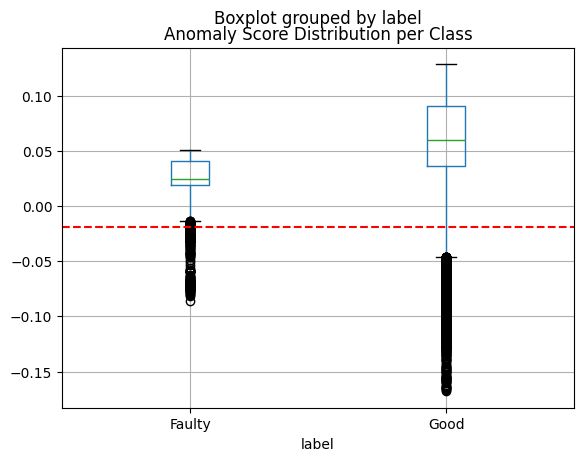

In [52]:
import matplotlib.pyplot as plt

scores = np.concatenate([healthy_scores, faulty_scores])
labels = ['Good'] * len(healthy_scores) + ['Faulty'] * len(faulty_scores)

plot_df = pd.DataFrame({'score': scores, 'label': labels})
plot_df.boxplot(column='score', by='label')
plt.axhline(y=threshold, color='r', linestyle='--')
plt.title('Anomaly Score Distribution per Class')
plt.show()

Somehow made it worse! Lmao
